# Challenge 2: Image Classification

## Hyperparameters

In [67]:
# --- Stochasticity -- 
SEED = 200

VALIDATION_SIZE = 0.2
IMAGE_SIZE = 224
INPUT_SIZE = 224


# --- Model Parameters ---
MODEL_TYPE = 'ResNet18'
PRETRAINED = True
NUM_CLASSES = 4

# --- Training Hyperparameters ---
LEARNING_RATE = 1e-3
BATCH_SIZE = 64
EPOCHS = 300
PATIENCE = 20
OPTIMIZER = 'AdamW'

# Regularisation
DROPOUT_RATE = 0.2       
L1_LAMBDA = 0             
L2_LAMBDA = 0            

# Plot config
PLOT_FLAG = True

# --- Data Settings ---
WHITELIST_PATH = 'whitelist/clean_train_data.txt'

TRAIN_DATA_PATH = 'train_data'
TRAIN_IMAGES_CACHE_PATH = 'cache/train_images_cache.npy'
TRAIN_MASKS_CACHE_PATH = 'cache/train_masks_cache.npy'
TRAIN_MASKED_IMAGES_CACHE_PATH = 'cache/train_masked_images_cache.npy' 
TRAIN_LABEL_PATH = 'train_labels.csv'

TEST_DATA_PATH = 'test_data'
TEST_IMAGE_CACHE_PATH  = 'cache/test_images_cache.npy'
TEST_MASKS_CACHE_PATH = 'cache/test_masks_cache.npy'
TEST_MASKED_IMAGES_CACHE_PATH = 'cache/test_masked_images_cache.npy' 




## Module imports

In [68]:
import cplot

import os
import torch
torch.manual_seed(SEED)
from torch import nn
from torchsummary import summary
from torch.utils.tensorboard import SummaryWriter
import torchvision
from torchvision.transforms import v2 as transforms
from torch.utils.data import TensorDataset, DataLoader
from torchview import draw_graph
import cv2
import copy
import shutil
from itertools import product
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
from PIL import Image
import matplotlib.gridspec as gridspec
import numpy as np
import csv
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.cm as cm  
import random
import math




if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")




PyTorch version: 2.9.1+cu130
Device: cuda


## Image and Label Loader

In [69]:
def get_whitelisted_ids(whitelist_path):
    if not whitelist_path or not os.path.exists(whitelist_path):
        return None
    ids = set()
    with open(whitelist_path, 'r') as f:
        for line in f:
            if line.strip():
                parts = line.strip().split('_')
                if len(parts) > 1:
                    ids.add(parts[1].split('.')[0])
    return sorted(list(ids), key=int)


In [70]:
def load_labels_aligned(csv_path, filtered_ids_list):
    print(f"Loading labels for {len(filtered_ids_list)} filtered images...")
    df = pd.read_csv(csv_path)
    id_col = df.columns[0]
    label_col = df.columns[1]
    df['clean_id'] = df[id_col].astype(str).apply(lambda x: x.split('_')[1].split('.')[0] if '_' in x else x)
    label_map = dict(zip(df['clean_id'], df[label_col]))
    
    final_labels = []
    for uid in filtered_ids_list:
        if uid in label_map:
            final_labels.append(label_map[uid])
        else:
            raise ValueError(f"Label missing for ID {uid}")
    return np.array(final_labels)

In [71]:
def get_sorted_filenames(folder):
    ids = set()
    for f in os.listdir(folder):
        if f.startswith("img_") and f.endswith(".png"): ids.add(f.split('_')[1].split('.')[0])
    return [f"img_{i}.png" for i in sorted(list(ids), key=int)]

## Dataloader creation

In [72]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as tv_transforms
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

PATCHES_DIR = "patches"
PATCH_LABEL_CSV = "label_patches.csv"

# Simple transforms for patches (use your existing norm)
norm_mean = [0.485, 0.456, 0.406]
norm_std  = [0.229, 0.224, 0.225]

patch_train_transforms = tv_transforms.Compose([
    tv_transforms.ToTensor(),  # from uint8 HWC -> float CHW in [0,1]
    tv_transforms.RandomHorizontalFlip(p=0.5),
    tv_transforms.RandomVerticalFlip(p=0.5),
    tv_transforms.RandomRotation(degrees=20),
    tv_transforms.Normalize(mean=norm_mean, std=norm_std),
])

patch_val_transforms = tv_transforms.Compose([
    tv_transforms.ToTensor(),
    tv_transforms.Normalize(mean=norm_mean, std=norm_std),
])

class PatchDataset(Dataset):
    def __init__(self, csv_path, root_dir, label_encoder, transform=None):
        self.df = pd.read_csv(csv_path)
        self.root_dir = root_dir
        self.le = label_encoder
        self.transform = transform
        # Encode labels once
        self.df["label_id"] = self.le.transform(self.df["label"])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.root_dir, row["patch_filename"])
        img_bgr = cv2.imread(img_path)
        if img_bgr is None:
            raise ValueError(f"Could not read patch {img_path}")
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        if self.transform is not None:
            img = self.transform(img_rgb)
        else:
            img = tv_transforms.ToTensor()(img_rgb)

        label = int(row["label_id"])
        return img, label

# ----------------------------------------------------
# BUILD PATCH TRAIN/VAL LOADERS FROM label_patches.csv
# ----------------------------------------------------
df_patches = pd.read_csv(PATCH_LABEL_CSV)
labels_str = df_patches["label"].values

# Fit label encoder ONCE here
label_encoder = LabelEncoder()
label_encoder.fit(labels_str)
NUM_CLASSES = len(label_encoder.classes_)
print("Classes:", label_encoder.classes_)

# Extract image ID from patch filename: img_0001_y32_x64.png -> "0001"
df_patches["img_id"] = df_patches["patch_filename"].str.extract(r"img_(\d+)_")[0]

# One label per image
img_ids = df_patches["img_id"].unique()
img_id_to_label = df_patches.groupby("img_id")["label"].first().to_dict()
img_labels = np.array([img_id_to_label[i] for i in img_ids])

train_img_ids, val_img_ids = train_test_split(
    img_ids,
    test_size=VALIDATION_SIZE,
    stratify=img_labels,
    random_state=SEED,
)

df_patches_train = df_patches[df_patches["img_id"].isin(train_img_ids)].reset_index(drop=True)
df_patches_val   = df_patches[df_patches["img_id"].isin(val_img_ids)].reset_index(drop=True)

patch_train_csv = "label_patches_train.csv"
patch_val_csv   = "label_patches_val.csv"
df_patches_train.to_csv(patch_train_csv, index=False)
df_patches_val.to_csv(patch_val_csv, index=False)

train_ds = PatchDataset(patch_train_csv, PATCHES_DIR, label_encoder, transform=patch_train_transforms)
val_ds   = PatchDataset(patch_val_csv,   PATCHES_DIR, label_encoder, transform=patch_val_transforms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f"Train patches: {len(train_ds)} | Val patches: {len(val_ds)}")


Classes: ['HER2(+)' 'Luminal A' 'Luminal B' 'Triple negative']
Train patches: 22991 | Val patches: 5685


Visualizing distribution of 28676 generated patches...


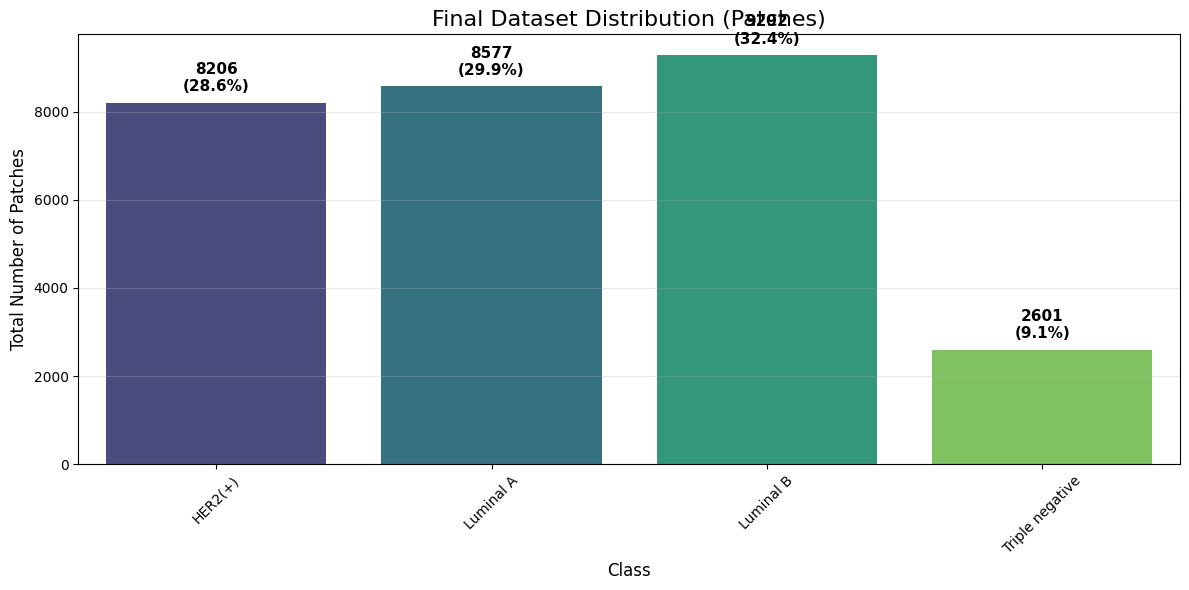

In [73]:
def plot_patch_distribution(labels, title="Final Dataset Distribution (Patches)"):

    # 1. Count classes
    unique_labels, counts = np.unique(labels, return_counts=True)
    
    # 2. Setup Plot
    plt.figure(figsize=(12, 6))
    ax = sns.barplot(x=unique_labels, y=counts, palette='viridis',
                     hue=unique_labels, legend=False)
    
    # 3. Styling
    plt.title(title, fontsize=16)
    plt.xlabel("Class", fontsize=12)
    plt.ylabel("Total Number of Patches", fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
    
    # 4. Add count labels on top of bars
    total_patches = int(counts.sum())
    for i, v in enumerate(counts):
        percentage = (v / total_patches) * 100
        ax.text(i, v + (max(counts) * 0.02),
                f"{v}\n({percentage:.1f}%)",
                ha='center', va='bottom',
                fontweight='bold', fontsize=11)
        
    plt.tight_layout()
    plt.show()


# Load patch labels from the new CSV and plot
df_patches = pd.read_csv(PATCH_LABEL_CSV)  # "challenge2/label_patches.csv"
labels = df_patches["label"].values

print(f"Visualizing distribution of {len(labels)} generated patches...")
plot_patch_distribution(labels)


## Cross Entropy

In [74]:
# Load patch labels
df_patches = pd.read_csv(PATCH_LABEL_CSV)   # "challenge2/label_patches.csv"
labels_str = df_patches["label"].values

# Encode with the same LabelEncoder you used for PatchDataset
label_encoder = LabelEncoder()
label_encoder.fit(labels_str)
NUM_CLASSES = len(label_encoder.classes_)
print("Classes:", label_encoder.classes_)

# Compute class weights on string labels
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels_str),
    y=labels_str
).astype(np.float32)

# Map weights into encoder class order
weights_by_class = dict(zip(np.unique(labels_str), class_weights))
weights_ordered = np.array([weights_by_class[c] for c in label_encoder.classes_], dtype=np.float32)

class_weights_t = torch.from_numpy(weights_ordered).to(device)
CRITERION = nn.CrossEntropyLoss(weight=class_weights_t)


Classes: ['HER2(+)' 'Luminal A' 'Luminal B' 'Triple negative']


## CNN Model

### Model Architecture

In [75]:
class SimpleCNN(nn.Module):

    def __init__(self, input_shape=(3, 224, 224), num_classes=2, dropout_rate=0.2):
        super().__init__()

        # First convolutional block: 16 filters
        self.conv0 = nn.Conv2d(input_shape[0], 16, kernel_size=3, padding='same')
        self.relu0 = nn.ReLU()
        self.mp0 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Second convolutional block: 32 filters
        self.conv1 = nn.Conv2d(16, 32, kernel_size=3, padding='same')
        self.relu1 = nn.ReLU()
        self.mp1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Third convolutional block: 64 filters
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding='same')
        self.relu2 = nn.ReLU()
        self.mp2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Fourth convolutional block: 128 filters
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding='same')
        self.relu3 = nn.ReLU()

        # Calculate flattened size after all blocks using a dummy forward pass
        with torch.no_grad():
            dummy_input = torch.zeros(1, *input_shape)
            dummy_output = self._forward_features(dummy_input)
            flattened_size = dummy_output.view(1, -1).shape[1]

        # Classification head
        self.classifier_head = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout_rate),
            nn.Linear(flattened_size, num_classes)
        )

    def _forward_features(self, x):
        """Forward pass through convolutional layers only."""
        x = self.mp0(self.relu0(self.conv0(x)))
        x = self.mp1(self.relu1(self.conv1(x)))
        x = self.mp2(self.relu2(self.conv2(x)))
        x = self.relu3(self.conv3(x))
        return x

    def forward(self, x):
        """Forward pass through the entire network."""
        x = self._forward_features(x)
        x = self.classifier_head(x)
        return x

In [76]:
import torch.nn as nn
import torch.nn.functional as F

class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_planes, planes, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(planes)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out

class ResNet20(nn.Module):
    def __init__(self, num_classes=4, hidden_size=256, dropout_rate=0.5):
        super(ResNet20, self).__init__()
        self.in_planes = 16

        # Initial Conv (3 -> 16 channels)
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)
        
        self.layer1 = self._make_layer(16, 3, stride=1)
        self.layer2 = self._make_layer(32, 3, stride=2)
        self.layer3 = self._make_layer(64, 3, stride=2)
        
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        
        # --- MLP CLASSIFIER HEAD (2 LAYERS) ---
        input_features = 64 * BasicBlock.expansion
        
        self.classifier_head = nn.Sequential(
            # LAYER 1: Projects from CNN features to hidden size
            nn.Linear(input_features, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            # LAYER 2: Projects from hidden size to number of classes
            nn.Linear(hidden_size, num_classes)
        )

    def _make_layer(self, planes, num_blocks, stride):
        strides = [stride] + [1]*(num_blocks-1)
        layers = []
        for stride in strides:
            layers.append(BasicBlock(self.in_planes, planes, stride))
            self.in_planes = planes * BasicBlock.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.avgpool(out)
        out = out.view(out.size(0), -1)
        
        # Pass through the 2-layer MLP head
        out = self.classifier_head(out)
        return out

### GradCam

In [77]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        # Hook the layer to capture gradients and activations
        # We use a weakref to avoid memory leaks or issues with deepcopy if needed
        self.handles = []
        self.handles.append(target_layer.register_forward_hook(self.save_activation))
        self.handles.append(target_layer.register_full_backward_hook(self.save_gradient))

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def remove_hooks(self):
        for handle in self.handles:
            handle.remove()

    def __call__(self, x, class_idx=None):
        # 1. Forward Pass
        self.model.eval()
        
        # Zero grads before starting
        self.model.zero_grad()
        
        logits = self.model(x)
        
        if class_idx is None:
            class_idx = logits.argmax(dim=1)
            
        # 2. Backward Pass
        score = logits[:, class_idx].squeeze()
        score.backward(retain_graph=True)
        
        # 3. Generate Map
        # Pool the gradients across the channels
        pooled_gradients = torch.mean(self.gradients, dim=[0, 2, 3])
        
        # Weight the activations by the gradients
        # The activation map is usually (1, C, H, W)
        activation = self.activations[0]
        
        # Vectorized weighting is faster
        for i in range(activation.shape[0]):
            activation[i, :, :] *= pooled_gradients[i]
            
        # Average the channels to get a 2D heatmap
        heatmap = torch.mean(activation, dim=0).cpu().detach().numpy()
        
        # ReLU on top (we only care about positive influence)
        heatmap = np.maximum(heatmap, 0)
        
        # Normalize
        if np.max(heatmap) != 0:
            heatmap /= np.max(heatmap)
            
        return heatmap, logits

In [78]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import cv2
import torch
import torch.nn as nn

def find_last_conv_layer(model):
    """
    Dynamically finds the last suitable layer for Grad-CAM.
    Priority:
    1. Last layer of 'layer4' (ResNet18/34/50/101/152)
    2. Last layer of 'layer3' (ResNet20, or smaller ResNets)
    3. Last layer of 'features' (VGG, AlexNet, DenseNet)
    4. Fallback: The very last nn.Conv2d module defined in the model.
    """
    # 1. Standard ResNet Convention (ImageNet)
    if hasattr(model, 'layer4') and len(model.layer4) > 0:
        return model.layer4[-1]

    # 2. CIFAR ResNet Convention (ResNet20, ResNet32, etc.)
    if hasattr(model, 'layer3') and len(model.layer3) > 0:
        return model.layer3[-1]

    # 3. VGG / DenseNet / SqueezeNet Convention
    if hasattr(model, 'features'):
        # iterate backwards to find a conv/block
        for layer in reversed(model.features):
            if isinstance(layer, (nn.Conv2d, nn.BatchNorm2d, nn.ReLU)):
                return layer

    # 4. Generic Fallback: Find the last Conv2d in the whole model
    last_conv = None
    for module in model.modules():
        if isinstance(module, nn.Conv2d):
            last_conv = module
    
    if last_conv is not None:
        return last_conv
        
    raise ValueError("Could not automatically find a target layer for Grad-CAM. Model has no recognized layers or Conv2d.")

def visualize_gradcam_with_mask_and_legend(model, images_tensor, masks_numpy, device, num_samples=3):
    """
    Plots: Original | Heatmap | GradCAM | Ground Truth Mask
    Model Invariant: Automatically detects the target layer.
    """
    model.eval()
    
    # Define Normalization (ImageNet standards)
    norm_mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1).to(device)
    norm_std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1).to(device)

    # Handle case where dataset is smaller than requested samples
    if len(images_tensor) < num_samples: 
        num_samples = len(images_tensor)
    
    # Select random indices
    indices = np.random.choice(len(images_tensor), num_samples, replace=False)
    
    # Variables to store hook data
    gradients = None
    activations = None

    # Hook Functions
    def backward_hook(module, grad_input, grad_output):
        nonlocal gradients
        gradients = grad_output[0]

    def forward_hook(module, input, output):
        nonlocal activations
        activations = output

    # --- DYNAMIC LAYER SELECTION ---
    try:
        target_layer = find_last_conv_layer(model)
        # print(f"Grad-CAM Target Layer detected: {target_layer}")
    except ValueError as e:
        print(e)
        return

    # Ensure gradients are calculated
    for param in model.parameters():
        param.requires_grad_(True)
        
    # Register Hooks
    handle_f = target_layer.register_forward_hook(forward_hook)
    handle_b = target_layer.register_full_backward_hook(backward_hook)

    fig, axes = plt.subplots(num_samples, 4, figsize=(20, 5 * num_samples))
    if num_samples == 1: axes = [axes] 

    for i, idx in enumerate(indices):
        # 1. Prepare Input
        raw_tensor = images_tensor[idx].unsqueeze(0).to(device)
        input_tensor = (raw_tensor - norm_mean) / norm_std
        
        # Prepare visualization original (0-255 uint8)
        original_img = raw_tensor.cpu().squeeze().permute(1, 2, 0).numpy()
        # Clip just in case floating point errors take it slightly outside 0-1
        original_img = np.clip(original_img, 0, 1)
        original_img = (original_img * 255).astype(np.uint8).copy()
        
        # 2. Forward Pass
        model.zero_grad()
        output = model(input_tensor)
        pred_idx = output.argmax(dim=1).item()
        
        # 3. Backward Pass
        score = output[:, pred_idx]
        score.backward()
        
        # 4. Grad-CAM Calculation
        # Global Average Pooling on Gradients
        pooled_gradients = torch.mean(gradients, dim=[0, 2, 3]).cpu()
        
        # Get activations
        act = activations.detach().cpu() # Shape: (1, C, H, W)
        
        # Weigh activations by gradients
        for j in range(act.shape[1]):
            act[:, j, :, :] *= pooled_gradients[j]
            
        # Average across channels to get heatmap
        heatmap = torch.mean(act, dim=1).squeeze()
        
        # Force float32 to avoid cv2 type errors
        heatmap = heatmap.numpy().astype(np.float32)
        
        # ReLU (Keep only positive influence)
        heatmap = np.maximum(heatmap, 0)
        
        # Normalize Heatmap
        if np.max(heatmap) != 0: 
            heatmap /= np.max(heatmap)
            
        # Resize Heatmap to Image Size
        heatmap = cv2.resize(heatmap, (original_img.shape[1], original_img.shape[0]))
        
        # Colorize
        heatmap_uint8 = np.uint8(255 * heatmap)
        heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
        heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
        
        # Superimpose
        superimposed_img = heatmap_color * 0.4 + original_img * 0.6
        superimposed_img = np.clip(superimposed_img, 0, 255).astype(np.uint8)

        # 5. Mask Overlay Logic
        mask_overlay = original_img.copy()
        if masks_numpy is not None:
            gt_mask = masks_numpy[idx]
            # Handle (H, W, 1) or (H, W) shapes
            if gt_mask.ndim == 3: gt_mask = gt_mask[:, :, 0]
            mask_bool = gt_mask > 0 
            
            green_color = np.array([0, 255, 0], dtype=np.uint8)
            if np.any(mask_bool):
                source_pixels = original_img[mask_bool].astype(np.float32)
                target_pixels = np.full_like(source_pixels, green_color)
                blended_pixels = (source_pixels * 0.7) + (target_pixels * 0.3)
                mask_overlay[mask_bool] = blended_pixels.astype(np.uint8)

        # 6. Plotting
        # Image
        axes[i][0].imshow(original_img)
        axes[i][0].set_title(f"Original\nSample {idx}")
        axes[i][0].axis('off')
        
        # Heatmap
        axes[i][1].imshow(heatmap_color)
        axes[i][1].set_title("Activation Heatmap")
        axes[i][1].axis('off')
        
        # Overlay
        axes[i][2].imshow(superimposed_img)
        axes[i][2].set_title(f"GradCAM (Pred: {pred_idx})")
        axes[i][2].axis('off')

        # Mask
        axes[i][3].imshow(mask_overlay)
        axes[i][3].set_title("Ground Truth Mask\n(Green Area)")
        axes[i][3].axis('off')

    # Colorbar layout
    plt.subplots_adjust(right=0.9)
    cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
    norm = plt.Normalize(vmin=0, vmax=1)
    sm = cm.ScalarMappable(cmap=cm.jet, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cbar_ax)
    cbar.set_ticks([0, 0.5, 1])
    cbar.set_ticklabels(['Low', 'Medium', 'High'])
    
    # Clean up hooks
    handle_f.remove()
    handle_b.remove()
    plt.show()

### Data Augmentation

In [79]:
import cv2
import torch
import torch.nn as nn
import torchstain

class MacenkoTransform(nn.Module):
    def __init__(self, ref_path, intensity_th=0.8):
        super().__init__()
        # Load reference image as RGB uint8 (H, W, 3)
        ref_bgr = cv2.imread(ref_path)
        if ref_bgr is None:
            raise ValueError(f"Could not read reference image at {ref_path}")
        ref_rgb = cv2.cvtColor(ref_bgr, cv2.COLOR_BGR2RGB)
        ref_t = torch.from_numpy(ref_rgb).permute(2, 0, 1).to(torch.uint8)  # (3, H, W)

        self.normalizer = torchstain.normalizers.MacenkoNormalizer(backend='torch')
        self.normalizer.fit(ref_t)  # expects (C, H, W)
        self.intensity_th = intensity_th

    def forward(self, img):
        """
        img: (C, H, W) or (B, C, H, W), values in [0,1] or [0,255]
        Returns: same shape, but stain-normalized, float in [0,1]
        """
        single = (img.ndim == 3)
        if single:
            img = img.unsqueeze(0)  # -> (1, C, H, W)

        out_list = []
        for x in img:  # x: (C, H, W)
            # to uint8 [0,255]
            x_np = x.permute(1, 2, 0).cpu().numpy()  # (H, W, C)
            if x_np.max() <= 1.0:
                x_np = (x_np * 255).astype("uint8")
            else:
                x_np = x_np.astype("uint8")

            x_t = torch.from_numpy(x_np).permute(2, 0, 1).to(torch.uint8)  # (C, H, W)

            # torchstain returns (I_norm, H, E) or similar
            norm_out = self.normalizer.normalize(x_t)
            if isinstance(norm_out, (tuple, list)):
                norm_t = norm_out[0]
            else:
                norm_t = norm_out

            # Ensure we are (C, H, W)
            if norm_t.ndim == 3 and norm_t.shape[0] != 3 and norm_t.shape[-1] == 3:
                norm_t = norm_t.permute(2, 0, 1)  # (H, W, 3) -> (3, H, W)

            norm_t = norm_t.float() / 255.0      # [0,1] float
            out_list.append(norm_t)

        out = torch.stack(out_list).to(img.device)  # (B, C, H, W)
        return out[0] if single else out


In [80]:
from torchvision import transforms

norm_mean = [0.485, 0.456, 0.406]
norm_std  = [0.229, 0.224, 0.225]

# --- TRANSFORMS PIPELINE: SIMPLE, OBVIOUS AUGS ---

ref_path = "train_data/img_0098.png"  # some representative training slide

macenko = MacenkoTransform(ref_path)

train_transforms = transforms.Compose([
    macenko,
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.Normalize(mean=norm_mean, std=norm_std),
])

val_transforms = transforms.Compose([
    macenko,
    transforms.Normalize(mean=norm_mean, std=norm_std),
])

test_transforms = transforms.Compose([
    macenko,
    transforms.Normalize(mean=norm_mean, std=norm_std),
])


# 1. SETUP: Define a transform that Fixes Color but DOES NOT Normalize
# (Because visualize_gradcam does normalization internally)
vis_transforms = transforms.Compose([
    macenko
])


print("Transforms Initialized. Using flips + small rotation + Normalize.")


Transforms Initialized. Using flips + small rotation + Normalize.


In [81]:
import numpy as np
import torch.nn.functional as F

def mixup_batch(x, y, alpha=0.4):
    """MixUp on a batch: returns mixed images and (y_a, y_b, lam)."""
    if alpha <= 0:
        return x, y, y, 1.0

    lam = np.random.beta(alpha, alpha)
    batch_size = x.size(0)
    index = torch.randperm(batch_size, device=x.device)
    mixed_x = lam * x + (1.0 - lam) * x[index]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def rand_bbox(size, lam):
    """Random bounding box for CutMix."""
    W = size[2]
    H = size[3]
    cut_rat = np.sqrt(1.0 - lam)
    cut_w = int(W * cut_rat)
    cut_h = int(H * cut_rat)

    cx = np.random.randint(W)
    cy = np.random.randint(H)

    x1 = np.clip(cx - cut_w // 2, 0, W)
    y1 = np.clip(cy - cut_h // 2, 0, H)
    x2 = np.clip(cx + cut_w // 2, 0, W)
    y2 = np.clip(cy + cut_h // 2, 0, H)

    return x1, y1, x2, y2

def cutmix_batch(x, y, alpha=1.0):
    """CutMix on a batch: returns mixed images and (y_a, y_b, lam)."""
    if alpha <= 0:
        return x, y, y, 1.0

    lam = np.random.beta(alpha, alpha)
    batch_size = x.size(0)
    index = torch.randperm(batch_size, device=x.device)

    shuffled_x = x[index]
    y_a, y_b = y, y[index]

    x1, y1, x2, y2 = rand_bbox(x.size(), lam)
    x[:, :, y1:y2, x1:x2] = shuffled_x[:, :, y1:y2, x1:x2]

    lam = 1.0 - ((x2 - x1) * (y2 - y1) / (x.size(-1) * x.size(-2)))
    return x, y_a, y_b, lam

def apply_mixup_cutmix(x, y, prob=0.7, mixup_alpha=0.4, cutmix_alpha=1.0):
    """Randomly apply MixUp or CutMix with total probability `prob`."""
    if np.random.rand() > prob:
        return x, y, y, 1.0  # no augmentation

    if np.random.rand() < 0.5:
        return mixup_batch(x, y, alpha=mixup_alpha)
    else:
        return cutmix_batch(x, y, alpha=cutmix_alpha)


### Training epoch

In [82]:
def train_one_epoch(model, train_loader, criterion, optimizer, scaler, device,
                    l1_lambda=0, l2_lambda=0,
                    use_mixup_cutmix=False, prob=0.0,
                    mixup_alpha=0.2, cutmix_alpha=1.0):
    """
    Patch-level training:
      - train_loader yields (B, C, H, W) and (B,) patch labels.
      - No MIL, no bags, no MixUp/CutMix by default.
    """
    model.train()
    running_loss = 0.0
    all_predictions = []
    all_targets = []

    for batch_idx, (inputs, targets) in enumerate(train_loader):
        if batch_idx == 0 or batch_idx == 1:
            print("Got first batch:", inputs.shape)
        inputs = inputs.to(device)
        targets = targets.to(device)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
            logits = model(inputs)              # (B, num_classes)
            loss = criterion(logits, targets)

            if l1_lambda > 0 or l2_lambda > 0:
                l1_norm = sum(p.abs().sum() for p in model.parameters())
                l2_norm = sum(p.pow(2).sum() for p in model.parameters())
                loss = loss + l1_lambda * l1_norm + l2_lambda * l2_norm

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * inputs.size(0)
        preds = logits.argmax(dim=1)
        all_predictions.append(preds.cpu().numpy())
        all_targets.append(targets.cpu().numpy())

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_f1 = f1_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions),
        average='macro'
    )
    return epoch_loss, epoch_f1

### Validating epoch

In [83]:

def validate_one_epoch(model, val_loader, criterion, device):
    """
    Patch-level validation:
      val_loader yields (B, C, H, W) and (B,) patch labels.
    """
    model.eval()
    running_loss = 0.0
    all_predictions = []
    all_targets = []

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)

            with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                logits = model(inputs)          # (B, num_classes)
                loss = criterion(logits, targets)

            running_loss += loss.item() * inputs.size(0)
            predictions = logits.argmax(dim=1)
            all_predictions.append(predictions.cpu().numpy())
            all_targets.append(targets.cpu().numpy())

    epoch_loss = running_loss / len(val_loader.dataset)
    epoch_f1 = f1_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions),
        average='macro'
    )
    return epoch_loss, epoch_f1

In [84]:
def fit(model, train_loader, val_loader, epochs, criterion, optimizer, scaler, device,
        l1_lambda=0, l2_lambda=0, patience=0, evaluation_metric="val_f1", mode='max',
        restore_best_weights=True, writer=None, verbose=10, experiment_name=""):

    # Initialize metrics tracking
    training_history = {
        'train_loss': [], 'val_loss': [],
        'train_f1': [], 'val_f1': []
    }

    # Configure early stopping if patience is set
    if patience > 0:
        patience_counter = 0
        best_metric = float('-inf') if mode == 'max' else float('inf')
        best_epoch = 0

    print(f"Training {epochs} epochs...")

    # Main training loop: iterate through epochs
    for epoch in range(1, epochs + 1):

        # Forward pass through training data, compute gradients, update weights
        train_loss, train_f1 = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, device, l1_lambda, l2_lambda
        )

        # Evaluate model on validation data without updating weights
        val_loss, val_f1 = validate_one_epoch(
            model, val_loader, criterion, device
        )

        # Store metrics for plotting and analysis
        training_history['train_loss'].append(train_loss)
        training_history['val_loss'].append(val_loss)
        training_history['train_f1'].append(train_f1)
        training_history['val_f1'].append(val_f1)



        # Print progress every N epochs or on first epoch
        if verbose > 0:
            if epoch % verbose == 0 or epoch == 1:
                print(f"Epoch {epoch:3d}/{epochs} | "
                    f"Train: Loss={train_loss:.4f}, F1 Score={train_f1:.4f} | "
                    f"Val: Loss={val_loss:.4f}, F1 Score={val_f1:.4f}")

        # Early stopping logic: monitor metric and save best model
        if patience > 0:
            current_metric = training_history[evaluation_metric][-1]
            is_improvement = (current_metric > best_metric) if mode == 'max' else (current_metric < best_metric)

            if is_improvement:
                best_metric = current_metric
                best_epoch = epoch
                torch.save(model.state_dict(), "models/"+experiment_name+'_model.pt')
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping triggered after {epoch} epochs.")
                    break

    # Restore best model weights if early stopping was used
    if restore_best_weights and patience > 0:
        model.load_state_dict(torch.load("models/"+experiment_name+'_model.pt'))
        print(f"Best model restored from epoch {best_epoch} with {evaluation_metric} {best_metric:.4f}")

    # Save final model if no early stopping
    if patience == 0:
        torch.save(model.state_dict(), "models/"+experiment_name+'_model.pt')

    # Close TensorBoard writer
    if writer is not None:
        writer.close()

    return model, training_history

In [85]:
# ---- PRINT UNIQUE IMAGE COUNTS (train/val) ----
# filenames look like: img_0001_y32_x64.png
train_img_ids_series = df_patches_train["patch_filename"].str.extract(r"img_(\d+)_")[0]
val_img_ids_series   = df_patches_val["patch_filename"].str.extract(r"img_(\d+)_")[0]

n_train_imgs = train_img_ids_series.nunique()
n_val_imgs   = val_img_ids_series.nunique()

print(f"Train images: {n_train_imgs}, Val images: {n_val_imgs}")
print(f"Train patches: {len(df_patches_train)}, Val patches: {len(df_patches_val)}")

Train images: 446, Val images: 112
Train patches: 22991, Val patches: 5685


### Training

In [86]:
import torch
import torch.nn as nn
from torchvision.models import mobilenet_v3_small, MobileNet_V3_Small_Weights

# ------------------------------
# CONFIG
# ------------------------------
NUM_CLASSES = len(label_encoder.classes_)  # use your patch label encoder
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Flag to enable/disable custom MLP classifier
USE_MLP_HEAD = False  # True -> use bottleneck MLP, False -> use default MobileNet head

# ------------------------------
# SMALL UTILITY: PARAM COUNTER
# ------------------------------
def print_param_stats(model, prefix=""):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    if prefix:
        prefix = prefix + " "
    print(
        f"{prefix}Trainable Parameters: {trainable:,} / {total:,} "
        f"({trainable / total * 100:.2f}% trainable)"
    )

# ------------------------------
# 1. LOAD PRETRAINED WEIGHTS (MobileNetV3-Small)
# ------------------------------
weights = MobileNet_V3_Small_Weights.IMAGENET1K_V1
vanilla_model = mobilenet_v3_small(weights=weights)

# ------------------------------
# 2. DEFINE / SELECT CLASSIFIER HEAD
# ------------------------------
if USE_MLP_HEAD:
    # MobileNetV3-Small classifier is typically:
    # [Linear(in -> 1024), Hardswish, Dropout, Linear(1024 -> 1000)]
    num_ftrs = vanilla_model.classifier[-1].in_features  # usually 1024

    vanilla_model.classifier = nn.Sequential(
        nn.Flatten(),
        # Layer 1: Compress -> 128
        nn.Linear(num_ftrs, 128),
        nn.BatchNorm1d(128),
        nn.ReLU(),
        nn.Dropout(p=0.5),
        # Layer 2: Bottleneck 128 -> 32
        nn.Linear(128, 32),
        nn.BatchNorm1d(32),
        nn.ReLU(),
        nn.Dropout(p=0.1),
        # Output Layer
        nn.Linear(32, NUM_CLASSES),
    )
    print("Using custom MLP classifier head.")
else:
    # Use the original MobileNet classifier but adjust output classes
    in_features = vanilla_model.classifier[-1].in_features
    vanilla_model.classifier[-1] = nn.Linear(in_features, NUM_CLASSES)
    num_ftrs = in_features
    print("Using simplified (modified default) MobileNetV3-Small classifier head.")

vanilla_model = vanilla_model.to(device)

# AMP scaler (disabled here, but kept for API compatibility)
scaler = torch.amp.GradScaler("cuda", enabled=False)

print(f"Initialized MobileNetV3-Small. Input Features: {num_ftrs}")
print_param_stats(vanilla_model, prefix="Initial")

# ---------------------------------------------------------
# PHASE 1: WARMUP (Head Only, PATCH-LEVEL)
# ---------------------------------------------------------
print("\n=== PHASE 1: WARMUP (Frozen Backbone) ===")
print("Goal: Stabilize the classifier head weights on patch data.")

# Freeze EVERYTHING first
for param in vanilla_model.parameters():
    param.requires_grad = False

# Unfreeze Head
for param in vanilla_model.classifier.parameters():
    param.requires_grad = True

print_param_stats(vanilla_model, prefix="Warmup")

# High LR for the Head
optimizer_warmup = torch.optim.Adam(vanilla_model.classifier.parameters(), lr=1e-3)


# --- PATCH-LEVEL TRAINING ---
# NOTE: now uses train_loader / val_loader built from label_patches.csv
best_model, history = fit(
    model=vanilla_model,
    train_loader=train_loader,    # <-- patch DataLoader
    val_loader=val_loader,        # <-- patch DataLoader
    epochs=20,
    criterion=CRITERION,
    optimizer=optimizer_warmup,
    scaler=scaler,
    device=device,
    writer=None,
    verbose=1,
    experiment_name="patch_mobilenetv3_small_warmup",
    patience=5,
)

# ---------------------------------------------------------
# PHASE 2: FINE-TUNING (PATCH-LEVEL)
# ---------------------------------------------------------
print("\n=== PHASE 2: FINE-TUNING ===")

# Map friendly names to actual modules
layer_map = {
    "features":   vanilla_model.features,   # convolutional backbone
    "classifier": vanilla_model.classifier, # head
}

# You can change this list to only ["classifier"] if you want lighter fine-tuning
layers_to_unfreeze = ["features", "classifier"]

# 1. Reset: Freeze EVERYTHING first
for param in vanilla_model.parameters():
    param.requires_grad = False

# 2. Unfreeze selected layers
for name in layers_to_unfreeze:
    if name in layer_map:
        module = layer_map[name]
        for param in module.parameters():
            param.requires_grad = True
        print(f" -> Unfrozen: {name}")
    else:
        print(f" -> Warning: '{name}' is not a valid layer name.")

print_param_stats(vanilla_model, prefix="Fine-tune")

# 3. Setup Optimizer (only unfrozen parameters)
optimizer_finetune = torch.optim.Adam(
    filter(lambda p: p.requires_grad, vanilla_model.parameters()),
    lr=1e-4,
    weight_decay=1e-4,
)

# 4. Train on patches again
best_model, history = fit(
    model=vanilla_model,
    train_loader=train_loader,    # <-- patch DataLoader
    val_loader=val_loader,        # <-- patch DataLoader
    epochs=300,
    criterion=CRITERION,
    optimizer=optimizer_finetune,
    scaler=scaler,
    device=device,
    writer=None,
    verbose=1,
    experiment_name="patch_mobilenetv3_small_finetune",
    patience=20,
)


Using simplified (modified default) MobileNetV3-Small classifier head.
Initialized MobileNetV3-Small. Input Features: 1024
Initial Trainable Parameters: 1,521,956 / 1,521,956 (100.00% trainable)

=== PHASE 1: WARMUP (Frozen Backbone) ===
Goal: Stabilize the classifier head weights on patch data.
Warmup Trainable Parameters: 594,948 / 1,521,956 (39.09% trainable)
Training 20 epochs...
Got first batch: torch.Size([64, 3, 128, 128])
Got first batch: torch.Size([64, 3, 128, 128])
Epoch   1/20 | Train: Loss=1.3813, F1 Score=0.2977 | Val: Loss=1.4018, F1 Score=0.2540
Got first batch: torch.Size([64, 3, 128, 128])
Got first batch: torch.Size([64, 3, 128, 128])
Epoch   2/20 | Train: Loss=1.3341, F1 Score=0.3308 | Val: Loss=1.4378, F1 Score=0.2515
Got first batch: torch.Size([64, 3, 128, 128])
Got first batch: torch.Size([64, 3, 128, 128])
Epoch   3/20 | Train: Loss=1.3156, F1 Score=0.3437 | Val: Loss=1.4996, F1 Score=0.2165
Got first batch: torch.Size([64, 3, 128, 128])
Got first batch: torch.

KeyboardInterrupt: 

In [ ]:
# ---------------------------------------------------------
# SAVE BEST MODEL LOCALLY
# ---------------------------------------------------------
import datetime

timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
model_dir = "saved_models"
os.makedirs(model_dir, exist_ok=True)

model_path = os.path.join(model_dir, f"mobilenetv3_small_patches_{timestamp}.pth")

# If fit(...) returns best_model, you can save that directly
torch.save(best_model.state_dict(), model_path)

print(f"Saved best MobileNetV3-Small patch model to: {model_path}")


Saved best MobileNetV3-Small patch model to: saved_models\mobilenetv3_small_patches_20251208_142502.pth


#### Plot Results

Generating comprehensive evaluation plots (patch-level)...


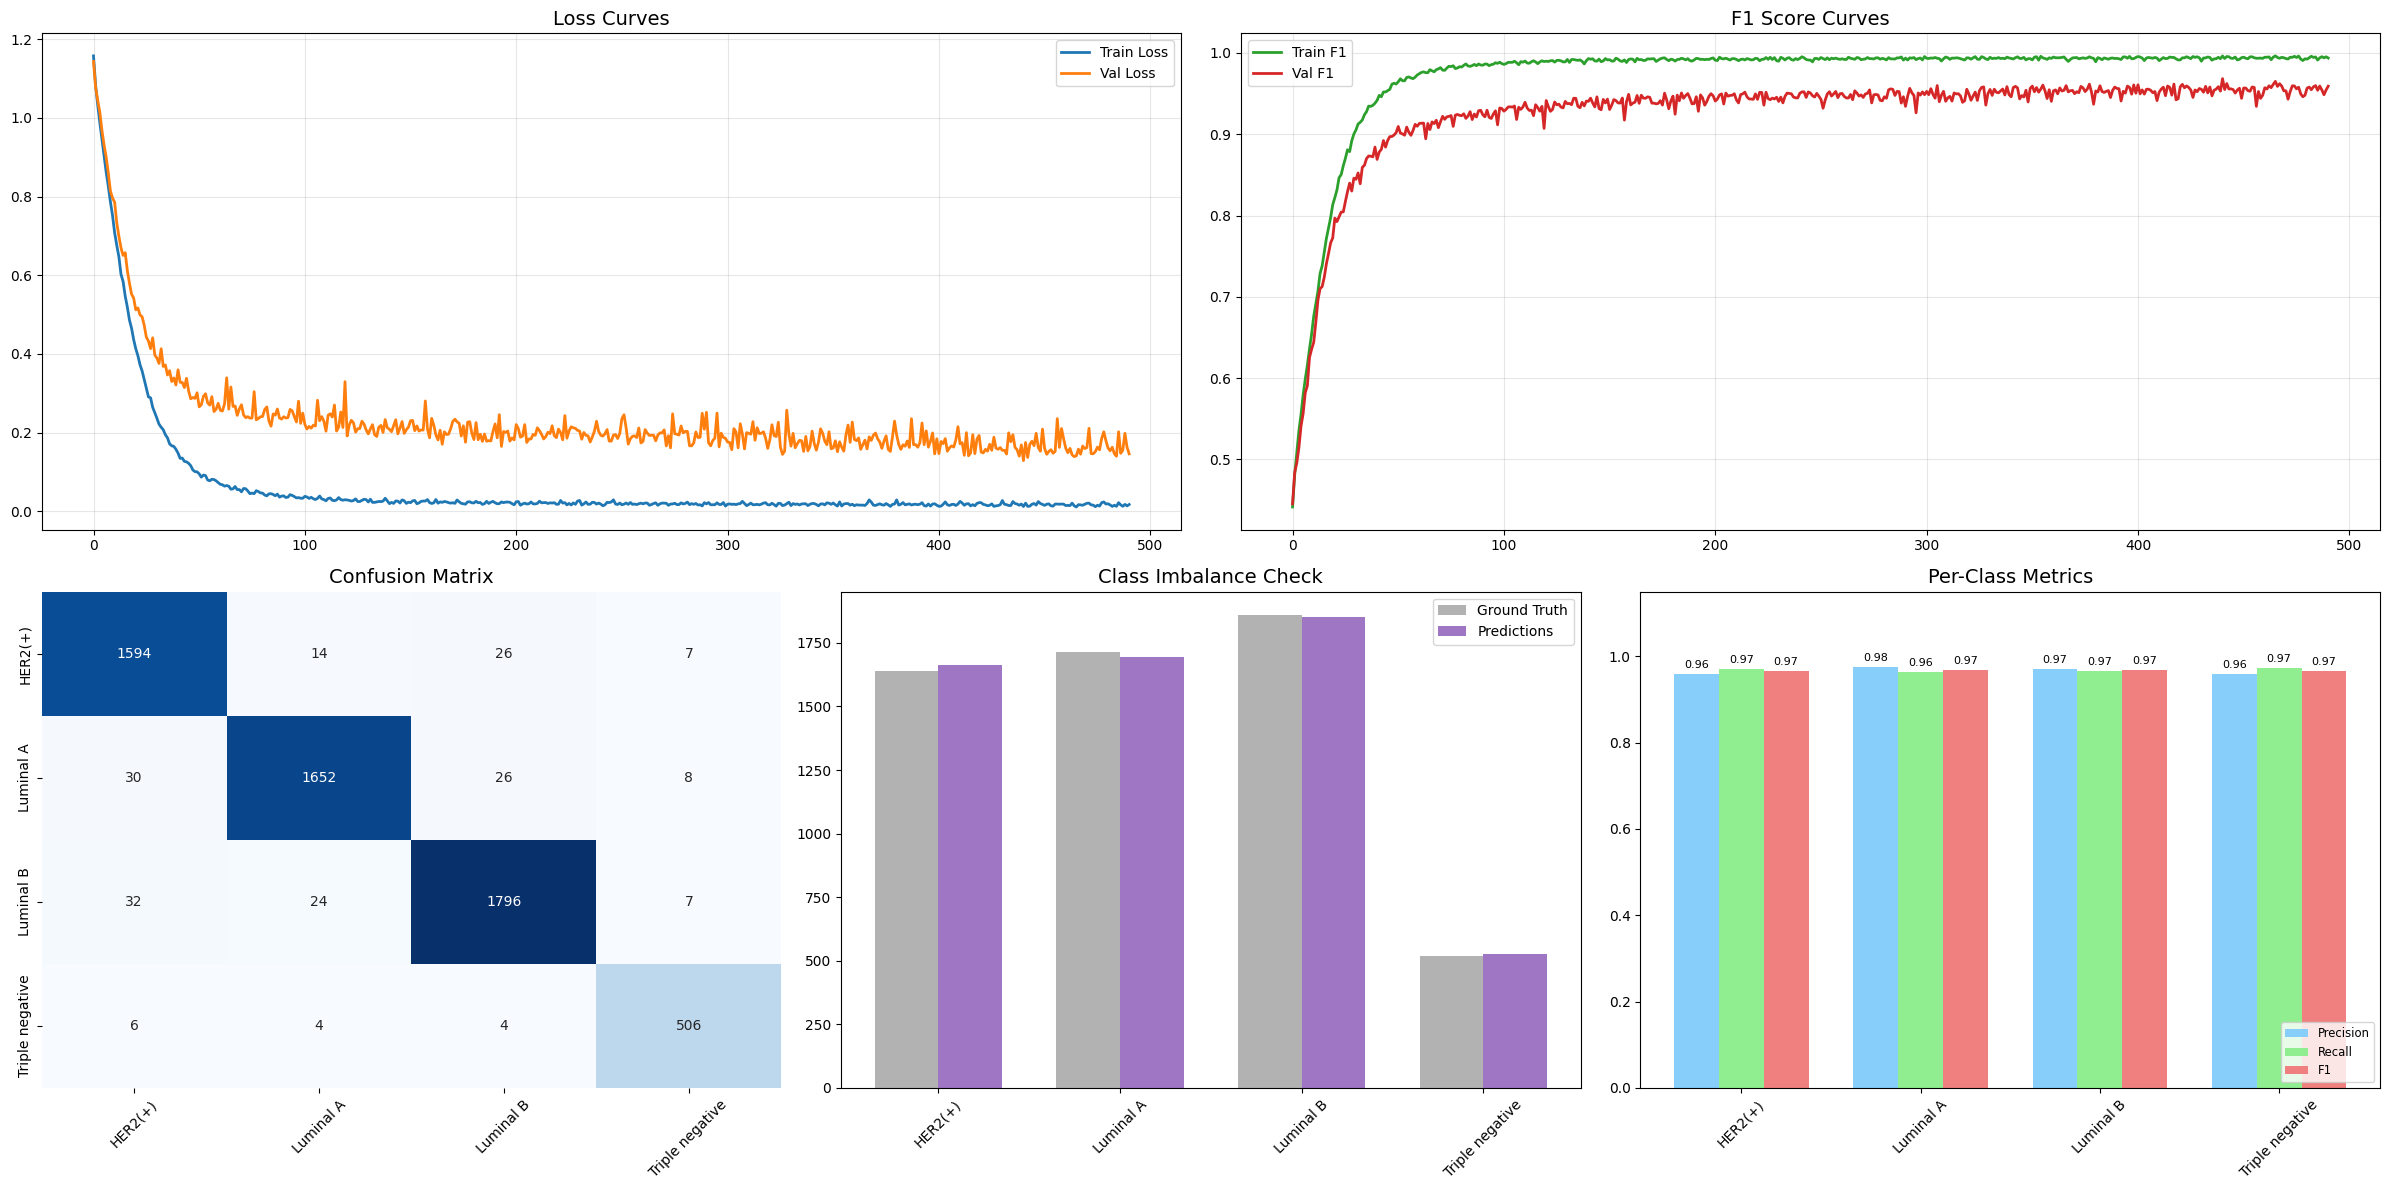

In [ ]:
from sklearn.metrics import precision_recall_fscore_support

def plot_comprehensive_results(model, loader, device, label_encoder, history=None):
    """
    Plots:
    Row 1: Training History (Loss & F1)
    Row 2: Confusion Matrix | Class Distribution | Per-Class Metrics

    Assumes:
      - loader yields (inputs, labels) with inputs of shape (B, C, H, W)
        already transformed (e.g., normalized) as in your val DataLoader.
    """
    print("Generating comprehensive evaluation plots (patch-level)...")
    
    # --- 1. Get Predictions ---
    model.eval()
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            # Direct forward; no extra transforms here
            outputs = model(inputs)
            preds = outputs.argmax(dim=1).cpu().numpy()

            all_preds.extend(preds)
            all_targets.extend(labels.cpu().numpy())
    
    all_preds    = np.array(all_preds)
    all_targets  = np.array(all_targets)
    class_names  = label_encoder.classes_
    
    # --- 2. Setup Figure Grid ---
    fig = plt.figure(figsize=(24, 12)) 
    gs = fig.add_gridspec(2, 6) 

    # =======================================================
    # ROW 1: HISTORY
    # =======================================================
    if history:
        ax1 = fig.add_subplot(gs[0, 0:3])
        ax1.plot(history['train_loss'], label='Train Loss', color='tab:blue', linewidth=2)
        ax1.plot(history['val_loss'],   label='Val Loss',   color='tab:orange', linewidth=2)
        ax1.set_title("Loss Curves", fontsize=14)
        ax1.legend(); ax1.grid(True, alpha=0.3)
        
        ax2 = fig.add_subplot(gs[0, 3:6])
        ax2.plot(history['train_f1'], label='Train F1', color='tab:green', linewidth=2)
        ax2.plot(history['val_f1'],   label='Val F1',   color='tab:red',   linewidth=2)
        ax2.set_title("F1 Score Curves", fontsize=14)
        ax2.legend(); ax2.grid(True, alpha=0.3)
    else:
        ax1 = fig.add_subplot(gs[0, 0:3]); ax1.text(0.5, 0.5, "No History", ha='center')
        ax2 = fig.add_subplot(gs[0, 3:6]); ax2.text(0.5, 0.5, "No History", ha='center')

    # =======================================================
    # ROW 2: ANALYSIS
    # =======================================================
    # 1. Confusion Matrix
    ax3 = fig.add_subplot(gs[1, 0:2])
    cm = confusion_matrix(all_targets, all_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=ax3, cbar=False)
    ax3.set_title("Confusion Matrix", fontsize=14)
    ax3.tick_params(axis='x', rotation=45)

    # 2. Prediction Distribution
    ax4 = fig.add_subplot(gs[1, 2:4])
    unique_true, true_counts = np.unique(all_targets, return_counts=True)
    pred_counts_full = np.zeros(len(class_names), dtype=int)
    unique_pred, pred_counts = np.unique(all_preds, return_counts=True)
    for cls, count in zip(unique_pred, pred_counts):
        pred_counts_full[cls] = count
    
    true_counts_full = np.zeros(len(class_names), dtype=int)
    for cls, count in zip(unique_true, true_counts):
        true_counts_full[cls] = count

    x = np.arange(len(class_names))
    width = 0.35
    ax4.bar(x - width/2, true_counts_full, width, label='Ground Truth', color='gray', alpha=0.6)
    ax4.bar(x + width/2, pred_counts_full, width, label='Predictions', color='tab:purple', alpha=0.9)
    ax4.set_title("Class Imbalance Check", fontsize=14)
    ax4.set_xticks(x); ax4.set_xticklabels(class_names, rotation=45)
    ax4.legend()

    # 3. Per-Class Metrics
    ax5 = fig.add_subplot(gs[1, 4:6])
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_targets, all_preds, labels=range(len(class_names)), zero_division=0
    )
    
    x = np.arange(len(class_names))
    width = 0.25
    rects1 = ax5.bar(x - width, precision, width, label='Precision', color='#87CEFA')
    rects2 = ax5.bar(x,         recall,    width, label='Recall',    color='#90EE90')
    rects3 = ax5.bar(x + width, f1,        width, label='F1',        color='#F08080')

    ax5.set_title('Per-Class Metrics', fontsize=14)
    ax5.set_xticks(x); ax5.set_xticklabels(class_names, rotation=45)
    ax5.legend(loc='lower right', fontsize='small')
    ax5.set_ylim(0, 1.15)
    
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            if height > 0.01:
                ax5.annotate(f'{height:.2f}',
                             xy=(rect.get_x() + rect.get_width() / 2, height),
                             xytext=(0, 3), textcoords="offset points",
                             ha='center', va='bottom', fontsize=8)
    autolabel(rects1); autolabel(rects2); autolabel(rects3)

    plt.tight_layout()
    plt.show()


# Call with your patch-level validation loader
plot_comprehensive_results(
    model=best_model,
    loader=val_loader,          # <-- NOT val_loader_mil
    device=device,
    label_encoder=label_encoder,
    history=history
)


--- GENERATING GRAD-CAM FOR VALIDATION PATCHES (No Masks) ---
Visualizing 4 validation patches with Grad-CAM...


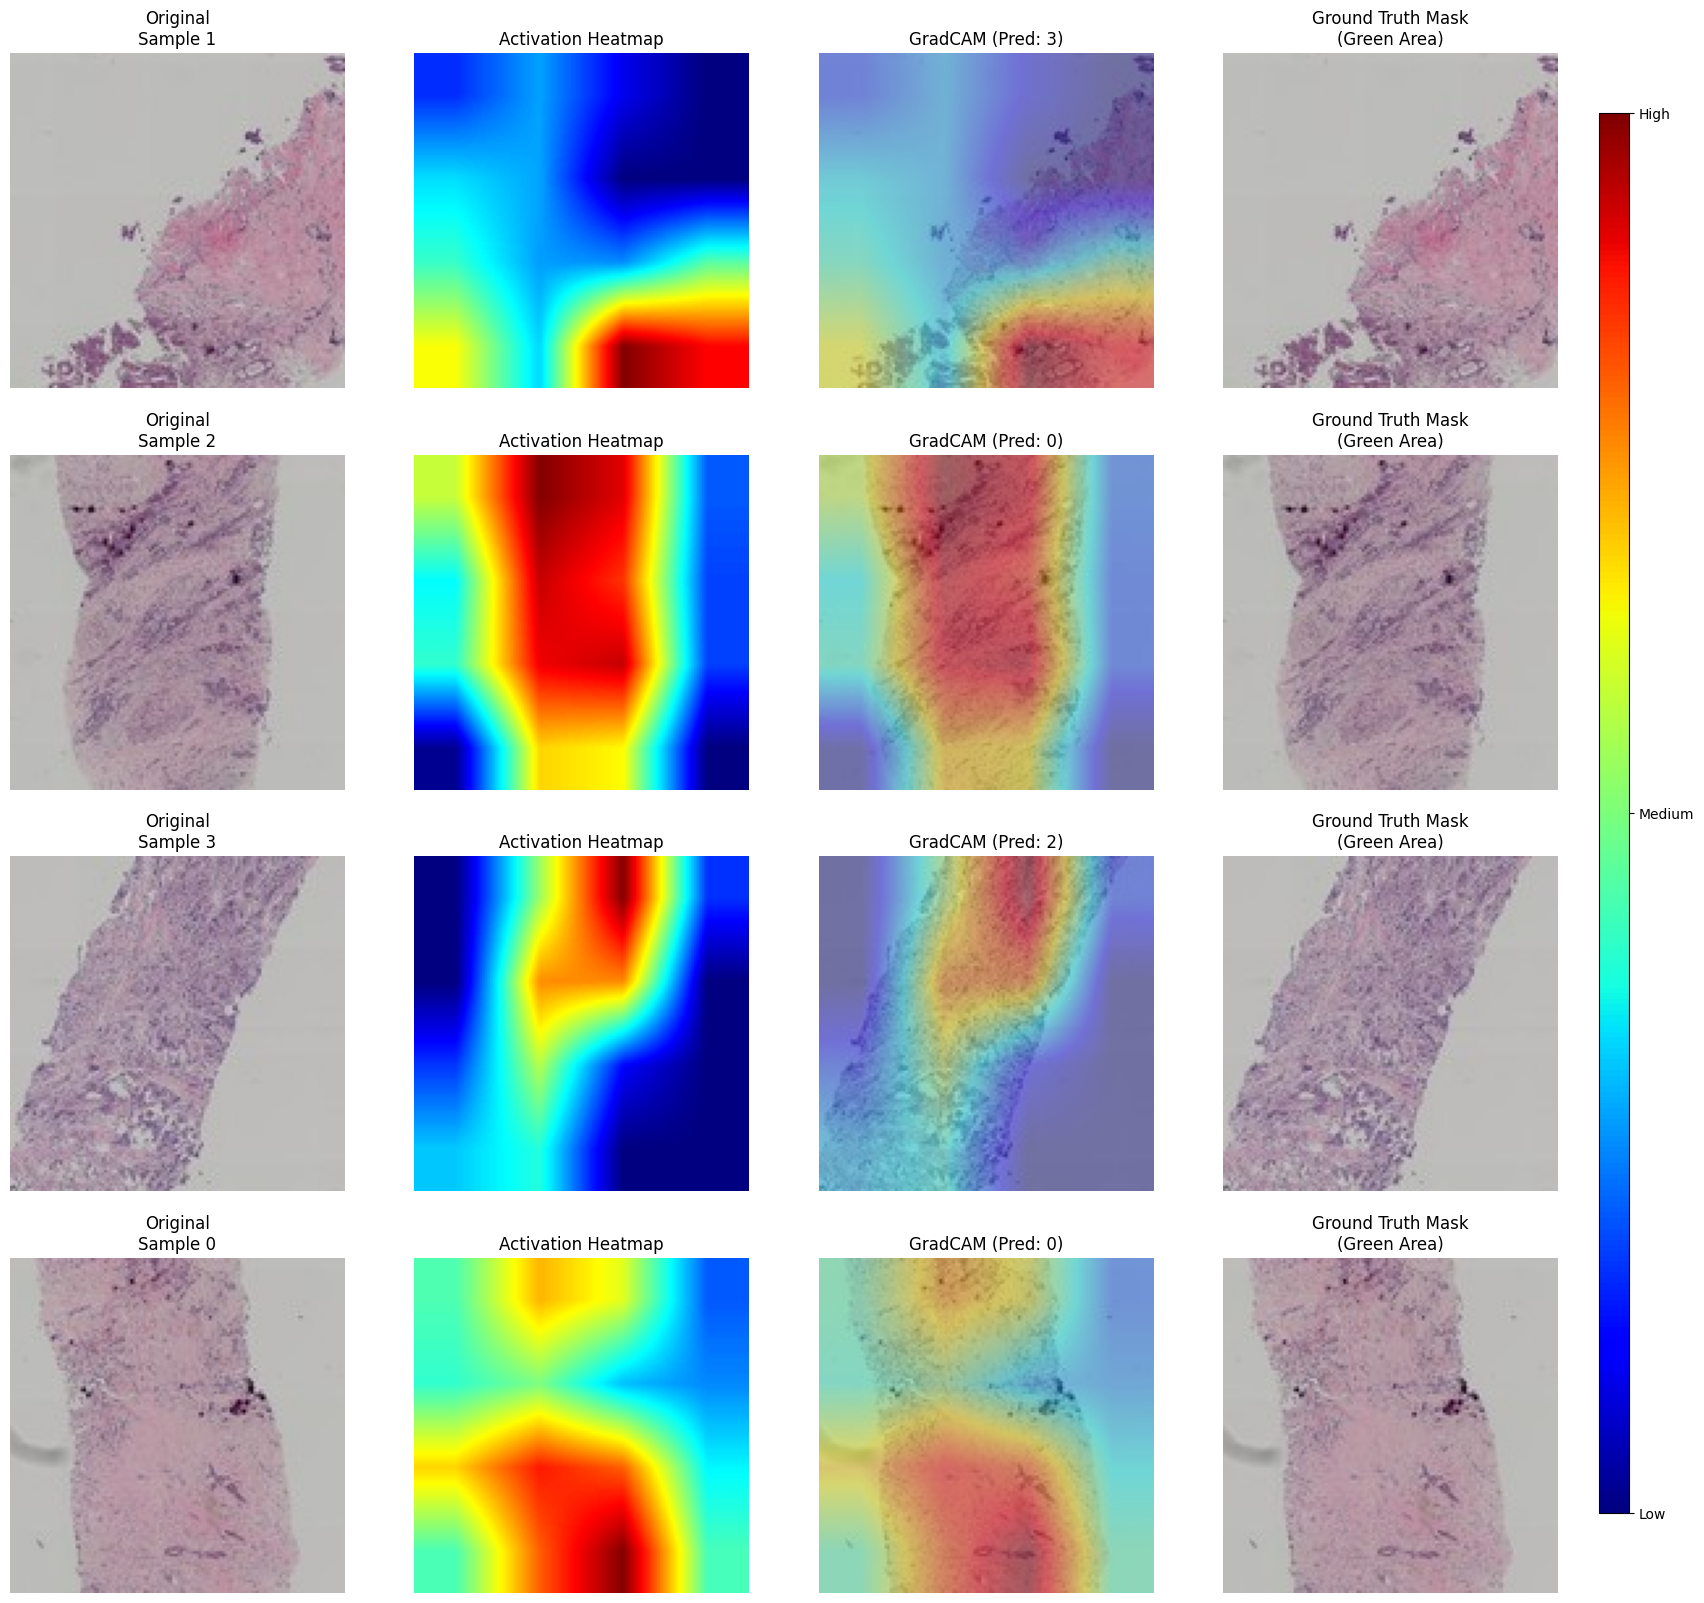

In [87]:
import cv2
import numpy as np
import torch
import random

print("--- GENERATING GRAD-CAM FOR VALIDATION PATCHES (No Masks) ---")

# Number of patches to visualize
NUM_SAMPLES = 4

# We assume:
# - best_model is your trained MobileNet/ResNet
# - val_loader yields (B, C, H, W) already normalized with norm_mean/norm_std
# - visualize_gradcam_with_mask_and_legend(...) is already defined and expects
#   images_tensor in [0,1] RGB, unnormalized
# - norm_mean, norm_std, device are defined as in your training code

best_model.eval()

viz_images_list = []

with torch.no_grad():
    for inputs, labels in val_loader:
        # inputs: (B, C, H, W), normalized
        # 1. Move to CPU and de-normalize back to [0,1] for visualization
        mean = torch.tensor(norm_mean).view(1, 3, 1, 1)
        std  = torch.tensor(norm_std).view(1, 3, 1, 1)

        inputs_denorm = inputs.cpu() * std + mean
        inputs_denorm = inputs_denorm.clamp(0.0, 1.0)  # ensure valid range

        # 2. Randomly pick up to NUM_SAMPLES patches from this batch
        idxs = list(range(inputs_denorm.size(0)))
        random.shuffle(idxs)
        idxs = idxs[:NUM_SAMPLES]

        viz_images_list = [inputs_denorm[i] for i in idxs]
        break  # only need the first batch

if len(viz_images_list) == 0:
    print("Error: val_loader is empty, cannot generate Grad-CAM.")
else:
    viz_tensor = torch.stack(viz_images_list)  # (N, 3, H, W)
    viz_masks_arr = None  # no lesion masks in the new pipeline

    print(f"Visualizing {viz_tensor.shape[0]} validation patches with Grad-CAM...")

    visualize_gradcam_with_mask_and_legend(
        model=best_model,
        images_tensor=viz_tensor,
        masks_numpy=viz_masks_arr,
        device=device,
        num_samples=viz_tensor.shape[0],
    )


## Test Prediction

In [ ]:
import os
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

# Paths must match your patch-generation code
TEST_PATCHES_DIR = "test_patches"
TEST_PATCH_CSV  = "test_patches.csv"

# -----------------------------
# Test patch dataset (no labels)
# -----------------------------
class TestPatchDataset(Dataset):
    def __init__(self, csv_path, root_dir, transform=None):
        self.df = pd.read_csv(csv_path)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        patch_path = os.path.join(self.root_dir, row["patch_filename"])
        img_bgr = cv2.imread(patch_path)
        if img_bgr is None:
            raise ValueError(f"Could not read test patch {patch_path}")
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        if self.transform is not None:
            img = self.transform(img_rgb)
        else:
            img = tv_transforms.ToTensor()(img_rgb)

        image_id = str(row["image_id"])  # e.g. "0001"
        return img, image_id

# -----------------------------
# Build test loader
# -----------------------------
test_patches_ds = TestPatchDataset(
    TEST_PATCH_CSV,
    TEST_PATCHES_DIR,
    transform=patch_val_transforms  # same as validation
)
test_patches_loader = DataLoader(
    test_patches_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print(f"Test patches: {len(test_patches_ds)}")

# How many distinct images in the CSV
df_test_patches = pd.read_csv(TEST_PATCH_CSV)
unique_image_ids_csv = df_test_patches["image_id"].astype(str).nunique()
print(f"Unique test images listed in CSV: {unique_image_ids_csv}")

# -----------------------------
# Predict and mean probabilities per image_id
# -----------------------------
best_model.eval()
probs_by_image = {}  # image_id -> list of prob vectors

with torch.no_grad():
    for inputs, image_ids in test_patches_loader:
        inputs = inputs.to(device)
        logits = best_model(inputs)
        probs  = F.softmax(logits, dim=1)  # (B, C)

        probs_np = probs.cpu().numpy()
        for i, img_id in enumerate(image_ids):
            if img_id not in probs_by_image:
                probs_by_image[img_id] = []
            probs_by_image[img_id].append(probs_np[i])

# -----------------------------
# Aggregate and build submission
# -----------------------------
rows = []
for img_id in sorted(probs_by_image.keys(), key=lambda x: int(x)):
    probs_stack = torch.tensor(probs_by_image[img_id])  # (N_patches, C)
    probs_mean = probs_stack.mean(dim=0).numpy()        # (C,)

    pred_idx = int(probs_mean.argmax())
    pred_label = label_encoder.inverse_transform([pred_idx])[0]

    # Ensure zero-padded 4-digit ID: img_0001.png
    img_id_int = int(img_id)
    sample_index = f"img_{img_id_int:04d}.png"
    rows.append((sample_index, pred_label))

submission_df = pd.DataFrame(rows, columns=["sample_index", "label"])
submission_df.to_csv("frame_generation_submission.csv", index=False)

print("Saved submission.csv")
print(submission_df.head())

# How many images actually got predictions
unique_pred_images = len(probs_by_image)
print(f"Unique test images with at least one tissue patch: {unique_pred_images}")


Test patches: 24280
Unique test images listed in CSV: 477
Saved submission.csv
   sample_index      label
0  img_0000.png  Luminal A
1  img_0001.png  Luminal B
2  img_0002.png  Luminal A
3  img_0003.png  Luminal B
4  img_0004.png    HER2(+)
Unique test images with at least one tissue patch: 477


--- GENERATING GRAD-CAM FOR TEST PATCHES (No Masks) ---
Visualizing 4 test patches with Grad-CAM...


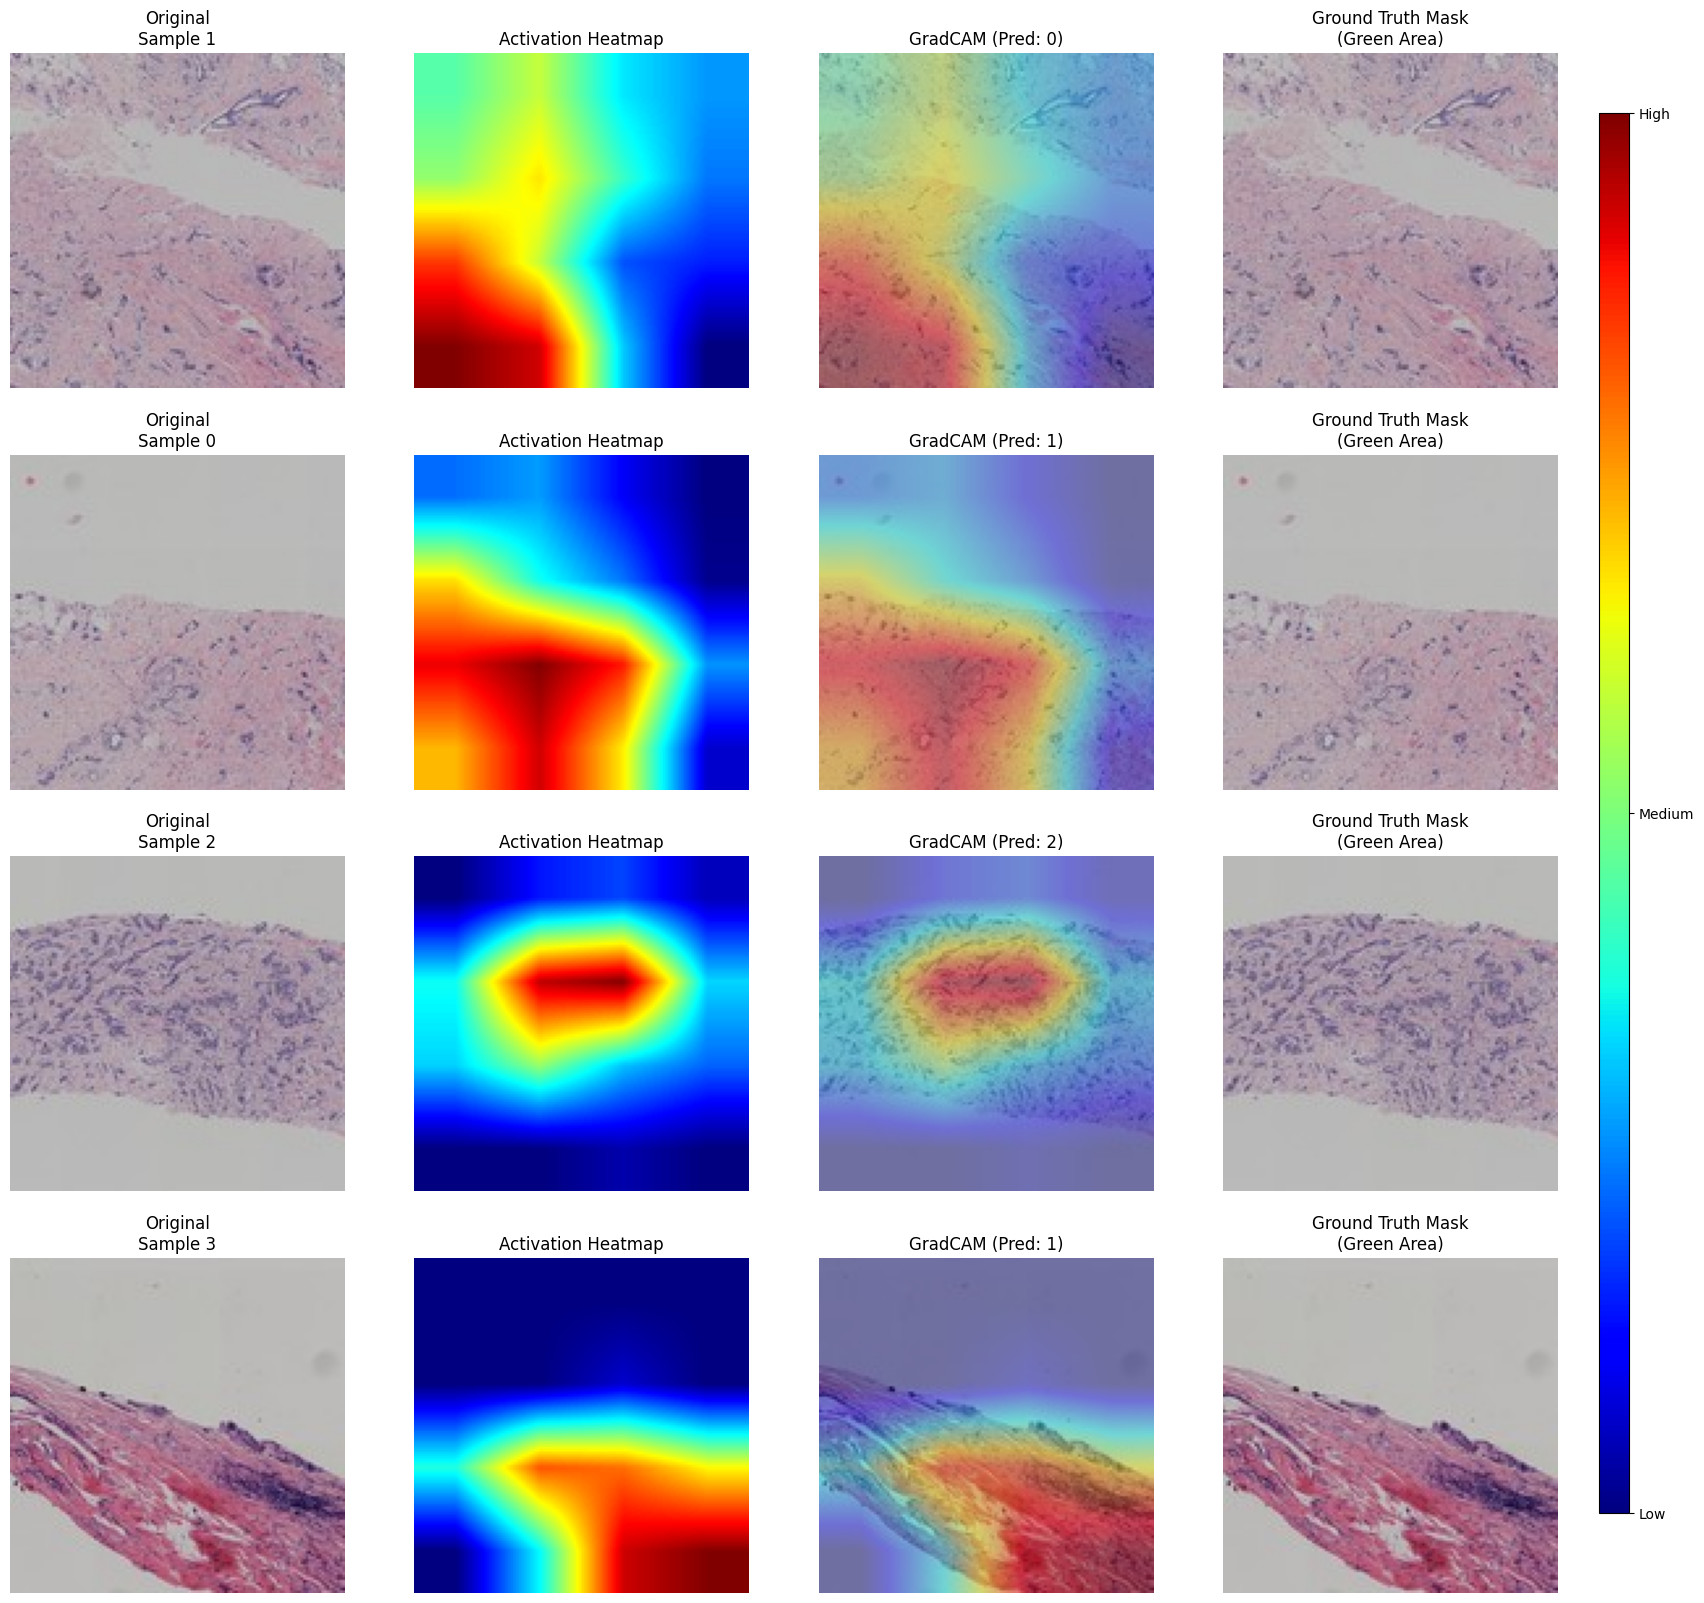

In [ ]:
import cv2
import numpy as np
import torch
import random

print("--- GENERATING GRAD-CAM FOR TEST PATCHES (No Masks) ---")

# Number of patches to visualize
NUM_SAMPLES = 4

# Assumes:
# - best_model is trained
# - test_patches_loader exists (built from test_patches + patch_val_transforms)
# - norm_mean, norm_std, device are defined
# - visualize_gradcam_with_mask_and_legend(...) is defined

best_model.eval()

viz_images_list = []

with torch.no_grad():
    for inputs, image_ids in test_patches_loader:
        # inputs: (B, C, H, W), already normalized
        mean = torch.tensor(norm_mean).view(1, 3, 1, 1)
        std  = torch.tensor(norm_std).view(1, 3, 1, 1)

        # De-normalize to [0,1] for visualization
        inputs_denorm = inputs.cpu() * std + mean
        inputs_denorm = inputs_denorm.clamp(0.0, 1.0)

        # Randomly pick up to NUM_SAMPLES patches from this batch
        idxs = list(range(inputs_denorm.size(0)))
        random.shuffle(idxs)
        idxs = idxs[:NUM_SAMPLES]

        viz_images_list = [inputs_denorm[i] for i in idxs]
        break  # only need first batch

if len(viz_images_list) == 0:
    print("Error: test_patches_loader is empty, cannot generate Grad-CAM.")
else:
    viz_tensor = torch.stack(viz_images_list)  # (N, 3, H, W)
    viz_masks_arr = None  # no masks for test

    print(f"Visualizing {viz_tensor.shape[0]} test patches with Grad-CAM...")

    visualize_gradcam_with_mask_and_legend(
        model=best_model,
        images_tensor=viz_tensor,
        masks_numpy=viz_masks_arr,
        device=device,
        num_samples=viz_tensor.shape[0],
    )



Checking Prediction Balance...


C:\Users\reluc\AppData\Local\Temp\ipykernel_20988\3581754478.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


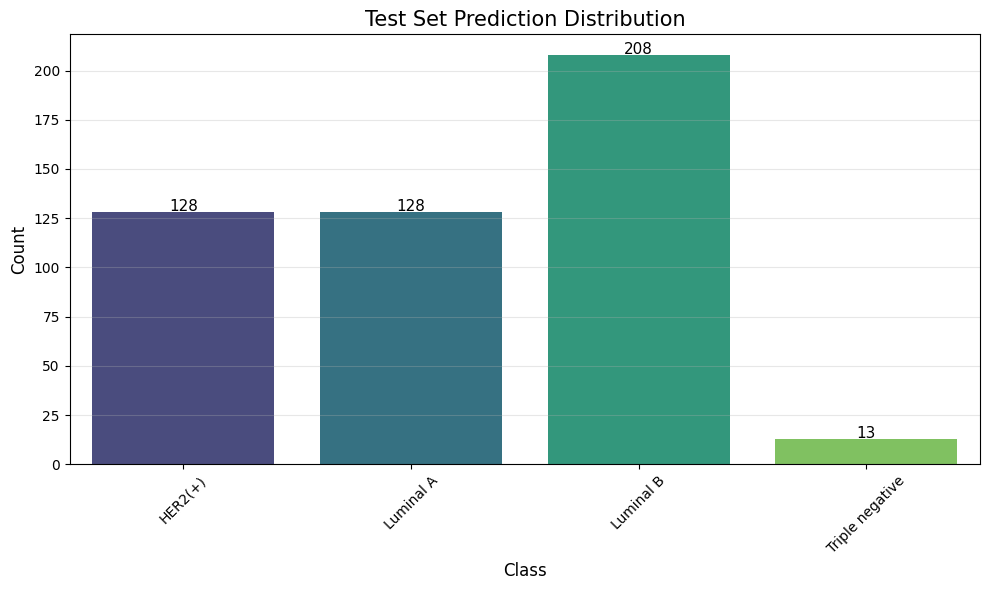

In [ ]:
def plot_test_distribution(submission_df):
    plt.figure(figsize=(10, 6))
    
    # Count the predicted labels
    counts = submission_df["label"].value_counts().sort_index()
    
    # Plot bar chart
    ax = sns.barplot(
        x=counts.index,
        y=counts.values,
        palette="viridis"
    )
    
    plt.title("Test Set Prediction Distribution", fontsize=15)
    plt.xlabel("Class", fontsize=12)
    plt.ylabel("Count", fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(axis="y", alpha=0.3)
    
    # Add numbers on top of bars
    for i, v in enumerate(counts.values):
        ax.text(i, v + 0.5, str(v), ha="center", fontsize=11)
        
    plt.tight_layout()
    plt.show()


# After you've built submission_df
print("\nChecking Prediction Balance...")
plot_test_distribution(submission_df)


In [ ]:
# =========================================================
# PATCH-LEVEL TRAINING + GRID-BASED IMAGE PREDICTION
# =========================================================

import os
import cv2
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as tv_transforms, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score
import torch
import torch.nn as nn
import torch.nn.functional as F

# -----------------------------
# CONFIG (adjust if needed)
# -----------------------------
PATCHES_DIR      = "patches"
PATCH_LABEL_CSV  = "label_patches.csv"
INPUT_SIZE       = INPUT_SIZE      # use your global INPUT_SIZE (e.g. 224)
STRIDE           = INPUT_SIZE // 2 # 50% overlap
TRAIN_FOLDER     = "train_data"
TEST_FOLDER      = TEST_DATA_PATH  # from your hyperparams
SEED             = 200

# -----------------------------
# TRANSFORMS FOR PATCHES
# -----------------------------
norm_mean = [0.485, 0.456, 0.406]
norm_std  = [0.229, 0.224, 0.225]

patch_train_transforms = tv_transforms.Compose([
    tv_transforms.ToTensor(),
    tv_transforms.RandomHorizontalFlip(p=0.5),
    tv_transforms.RandomVerticalFlip(p=0.5),
    tv_transforms.RandomRotation(degrees=20),
    tv_transforms.Normalize(mean=norm_mean, std=norm_std),
])

patch_val_transforms = tv_transforms.Compose([
    tv_transforms.ToTensor(),
    tv_transforms.Normalize(mean=norm_mean, std=norm_std),
])

# -----------------------------
# DATASET FOR PATCHES
# -----------------------------
class PatchDataset(Dataset):
    def __init__(self, df_patches, root_dir, label_encoder, transform=None):
        self.df = df_patches.reset_index(drop=True)
        self.root_dir = root_dir
        self.le = label_encoder
        self.transform = transform

        # Encode labels once
        self.df['label_id'] = self.le.transform(self.df['label'])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.root_dir, row['patch_filename'])
        img_bgr = cv2.imread(img_path)
        if img_bgr is None:
            raise ValueError(f"Could not read patch {img_path}")
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        if self.transform is not None:
            img = self.transform(img_rgb)
        else:
            img = tv_transforms.ToTensor()(img_rgb)

        label = int(row['label_id'])
        return img, label

# -----------------------------
# LOAD PATCH LABELS & BUILD LOADERS
# -----------------------------
df_patches_full = pd.read_csv(PATCH_LABEL_CSV)
labels_str = df_patches_full['label'].values

label_encoder = LabelEncoder()
label_encoder.fit(labels_str)
NUM_CLASSES = len(label_encoder.classes_)
print("Classes:", label_encoder.classes_)

train_idx, val_idx = train_test_split(
    np.arange(len(df_patches_full)),
    test_size=VALIDATION_SIZE,
    stratify=labels_str,
    random_state=SEED
)

df_patches_train = df_patches_full.iloc[train_idx]
df_patches_val   = df_patches_full.iloc[val_idx]

train_ds = PatchDataset(df_patches_train, PATCHES_DIR, label_encoder, transform=patch_train_transforms)
val_ds   = PatchDataset(df_patches_val,   PATCHES_DIR, label_encoder, transform=patch_val_transforms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

print(f"Train patches: {len(train_ds)} | Val patches: {len(val_ds)}")

# -----------------------------
# BUILD MODEL (USE YOUR CHOICE)
# -----------------------------
def build_model(model_type, num_classes):
    if model_type == "ResNet20":
        return ResNet20(num_classes=num_classes, hidden_size=256, dropout_rate=DROPOUT_RATE).to(device)
    elif model_type == "SimpleCNN":
        return SimpleCNN(input_shape=(3, INPUT_SIZE, INPUT_SIZE),
                         num_classes=num_classes,
                         dropout_rate=DROPOUT_RATE).to(device)
    elif model_type == "ResNet18":
        m = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1 if PRETRAINED else None)
        in_features = m.fc.in_features
        m.fc = nn.Linear(in_features, num_classes)
        return m.to(device)
    else:
        raise ValueError(f"Unknown MODEL_TYPE: {model_type}")

model = build_model(MODEL_TYPE, NUM_CLASSES)
print(f"Using model: {MODEL_TYPE}")

# -----------------------------
# LOSS WITH CLASS WEIGHTS (PATCH-LEVEL)
# -----------------------------
class_weights = compute_class_weight('balanced', classes=np.unique(labels_str), y=labels_str)
class_weights = class_weights.astype(np.float32)
class_weights_t = torch.from_numpy(class_weights).to(device)

CRITERION = nn.CrossEntropyLoss(weight=class_weights_t)

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
scaler = torch.amp.GradScaler(device.type)

# -----------------------------
# TRAIN ON PATCHES (uses your fit/train_one_epoch/validate_one_epoch)
# -----------------------------
best_model, history = fit(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    criterion=CRITERION,
    optimizer=optimizer,
    scaler=scaler,
    device=device,
    l1_lambda=L1_LAMBDA,
    l2_lambda=L2_LAMBDA,
    patience=PATIENCE,
    evaluation_metric="val_f1",
    mode="max",
    restore_best_weights=True,
    writer=None,
    verbose=1,
    experiment_name=f"patch_{MODEL_TYPE}"
)

# -----------------------------
# TISSUE FILTER FOR INFERENCE
# -----------------------------
def patch_has_tissue_infer(patch_rgb,
                           frac_color_thresh=0.30,
                           var_thresh=20.0):
    """
    Color-aware tissue filter:
      - require enough 'colored' pixels (stained tissue)
      - and enough texture (variance).
    This avoids muddy/blank background patches. [web:260]
    """
    patch_hsv = cv2.cvtColor(patch_rgb, cv2.COLOR_RGB2HSV)
    Hc, Sc, Vc = cv2.split(patch_hsv)

    sat_thresh = 25   # S > 25: avoid gray/muddy background
    val_max    = 240  # V < 240: avoid very bright background

    color_mask = (Sc > sat_thresh) & (Vc < val_max)
    frac_color = color_mask.mean()

    gray = cv2.cvtColor(patch_rgb, cv2.COLOR_RGB2GRAY)
    var_gray = gray.var()

    return (frac_color >= frac_color_thresh) and (var_gray >= var_thresh)

# -----------------------------
# GRID-BASED IMAGE PREDICTION
# -----------------------------
def predict_image_grid(image_path, model, device, encoder,
                       input_size=INPUT_SIZE, stride=STRIDE):
    """
    Slide a grid over the image, classify only tissue patches,
    and average softmax probabilities to get image-level prediction.
    """
    model.eval()
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        raise ValueError(f"Could not read image {image_path}")
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    H, W, _ = img_rgb.shape

    probs_list = []

    with torch.no_grad():
        for y in range(0, max(1, H - input_size + 1), stride):
            for x in range(0, max(1, W - input_size + 1), stride):
                if y + input_size > H or x + input_size > W:
                    continue
                patch = img_rgb[y:y+input_size, x:x+input_size]

                # skip background patches
                if not patch_has_tissue_infer(patch):
                    continue

                patch_t = patch_val_transforms(patch).unsqueeze(0).to(device)
                logits = model(patch_t)
                probs = F.softmax(logits, dim=1)
                probs_list.append(probs.cpu().numpy())

    if len(probs_list) == 0:
        # Fallback: central patch if nothing passes the filter
        cy = max(0, H // 2 - input_size // 2)
        cx = max(0, W // 2 - input_size // 2)
        cy = min(cy, H - input_size)
        cx = min(cx, W - input_size)
        patch = img_rgb[cy:cy+input_size, cx:cx+input_size]
        patch_t = patch_val_transforms(patch).unsqueeze(0).to(device)
        with torch.no_grad():
            logits = model(patch_t)
            probs = F.softmax(logits, dim=1)
        probs_avg = probs.cpu().numpy()[0]
    else:
        probs_mat = np.concatenate(probs_list, axis=0)  # (N_patches, C)
        probs_avg = probs_mat.mean(axis=0)              # (C,)

    pred_idx = int(np.argmax(probs_avg))
    pred_label = encoder.inverse_transform([pred_idx])[0]
    return pred_label, probs_avg

# -----------------------------
# BUILD SUBMISSION
# -----------------------------
rows = []
test_files = [f for f in os.listdir(TEST_FOLDER)
              if f.startswith("img_") and f.endswith(".png")]
test_ids = sorted([f.split("_")[1].split(".")[0] for f in test_files], key=int)

for img_id in test_ids:
    img_path = os.path.join(TEST_FOLDER, f"img_{img_id}.png")
    label, _ = predict_image_grid(
        image_path=img_path,
        model=best_model,
        device=device,
        encoder=label_encoder,
        input_size=INPUT_SIZE,
        stride=STRIDE
    )
    rows.append((f"img_{img_id}.png", label))

submission_df = pd.DataFrame(rows, columns=["sample_index", "label"])
submission_df.to_csv("submission.csv", index=False)
print("Saved submission.csv")
print(submission_df.head())


Classes: ['HER2(+)' 'Luminal A' 'Luminal B' 'Triple negative']
Train patches: 22940 | Val patches: 5736
Using model: ResNet18


NameError: name 'fit' is not defined